# MelOPark - Data Wrangling Pipeline & Restriction Translator(RT)
**Dataset:** On-street Car Park Bay Restrictions — City of Melbourne  
**Team:** TE31  FIT5120  Monash University  
**Pipeline:** EDA -> Bronze -> Silver -> Gold -> Export  
**Author:** Mowlya  Data Science Team

#### Date: 10th, April 2026
---
### Methodology
This notebook follows the standard data wrangling methodology:
1. **EDA** - Understand the raw data structure, distributions and quality
2. **Bronze** - Ingest raw data with minimal cleaning
3. **Silver** - Type-cast, reshape, validate and standardise
4. **Gold** - Business logic, plain English translation, feature engineering
5. **Export** - Save outputs for AWS and downstream use
---

## 0. Setup & Install

In [1]:
import sys
!{sys.executable} -m pip install pandas requests matplotlib seaborn pyarrow --quiet

import pandas as pd
import numpy as np
import requests
import re
import warnings
from datetime import datetime, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F8F8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
PALETTE = ['#534AB7','#1D9E75','#D85A30','#BA7517','#E24B4A','#378ADD','#639922']

print(' Setup complete')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


/Users/mowlya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


 Setup complete
   pandas  2.3.3
   numpy   2.0.2


---
## 1. Data Ingestion

In [2]:
BASE_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/on-street-car-park-bay-restrictions/records"
PAGE_SIZE  = 100
MAX_RECORDS = 10000

all_records = []
offset = 0

while offset < MAX_RECORDS:
    params = {"limit": PAGE_SIZE, "offset": offset}
    resp = requests.get(BASE_URL, params=params, timeout=30)
    resp.raise_for_status()
    data  = resp.json()
    batch = data.get("results", [])
    all_records.extend(batch)
    print(f"  Fetched {len(all_records):,} records...", end="\r")
    if len(batch) < PAGE_SIZE:
        break
    offset += PAGE_SIZE

df_raw = pd.DataFrame(all_records)
print(f"\n Total records loaded: {len(df_raw):,}")
print(f"   Columns: {df_raw.shape[1]}")
df_raw.head(3)

  Fetched 4,263 records...
 Total records loaded: 4,263
   Columns: 62


,bayid,deviceid,description1,description2,description3,description4,description5,description6,disabilityext1,disabilityext2,disabilityext3,disabilityext4,disabilityext5,disabilityext6,duration1,duration2,duration3,duration4,duration5,duration6,effectiveonph1,effectiveonph2,effectiveonph3,effectiveonph4,effectiveonph5,effectiveonph6,endtime1,endtime2,endtime3,endtime4,endtime5,endtime6,exemption1,exemption2,exemption3,exemption4,exemption5,exemption6,fromday1,fromday2,fromday3,fromday4,fromday5,fromday6,starttime1,starttime2,starttime3,starttime4,starttime5,starttime6,today1,today2,today3,today4,today5,today6,typedesc1,typedesc2,typedesc3,typedesc4,typedesc5,typedesc6
0,9003,29960,4P MTR M-F 10:00-18:30,4P MTR SAT 7:30-12:30,None,None,None,None,480,480.00,NaN,NaN,NaN,NaN,240,240.00,NaN,NaN,NaN,NaN,0,0.00,NaN,NaN,NaN,NaN,0001-01-01T18:30:00+00:00,0001-01-01T12:30:00+00:00,None,None,None,None,None,None,None,None,None,None,1,6.00,NaN,NaN,NaN,NaN,0001-01-01T10:00:00+00:00,0001-01-01T07:30:00+00:00,None,None,None,None,5,6.00,NaN,NaN,NaN,NaN,4P Meter,4P Meter,None,None,None,None
1,6034,30043,2P MTR M-SAT 7:30-18:30,2P SUN 7:30-18:30,None,None,None,None,240,240.00,NaN,NaN,NaN,NaN,120,120.00,NaN,NaN,NaN,NaN,0,0.00,NaN,NaN,NaN,NaN,0001-01-01T18:30:00+00:00,0001-01-01T18:30:00+00:00,None,None,None,None,None,None,None,None,None,None,1,0.00,NaN,NaN,NaN,NaN,0001-01-01T07:30:00+00:00,0001-01-01T07:30:00+00:00,None,None,None,None,6,0.00,NaN,NaN,NaN,NaN,2P Meter,2P,None,None,None,None
2,8696,27823,1P RPA 7:30am-10pm M-SUN,None,None,None,None,None,120,NaN,NaN,NaN,NaN,NaN,60,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,0001-01-01T22:00:00+00:00,None,None,None,None,None,Resident Permit Area 1B,None,None,None,None,None,1,NaN,NaN,NaN,NaN,NaN,0001-01-01T07:30:00+00:00,None,None,None,None,None,0,NaN,NaN,NaN,NaN,NaN,1P,None,None,None,None,None


---
## 2. EDA - Exploratory Data Analysis
> **Goal:** Understand structure, distributions, missing values and anomalies BEFORE cleaning.

In [3]:
# ── 2.1 Basic shape and types ────────────────────────────
print("=" * 55)
print("EDA STEP 1 — Dataset shape and column types")
print("=" * 55)
print(f"Rows:    {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print("\nColumn list:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2}. {col:35} dtype: {df_raw[col].dtype}")

EDA STEP 1 — Dataset shape and column types
Rows:    4,263
Columns: 62

Column list:
   1. bayid                               dtype: int64
   2. deviceid                            dtype: int64
   3. description1                        dtype: object
   4. description2                        dtype: object
   5. description3                        dtype: object
   6. description4                        dtype: object
   7. description5                        dtype: object
   8. description6                        dtype: object
   9. disabilityext1                      dtype: int64
  10. disabilityext2                      dtype: float64
  11. disabilityext3                      dtype: float64
  12. disabilityext4                      dtype: float64
  13. disabilityext5                      dtype: float64
  14. disabilityext6                      dtype: float64
  15. duration1                           dtype: int64
  16. duration2                           dtype: float64
  17. duration3  

In [4]:
# ── 2.2 Find the correct bay_id column ──────────────────
print("=" * 55)
print("EDA STEP 2 — Identify bay ID column")
print("=" * 55)

id_candidates = [c for c in df_raw.columns if 'bay' in c.lower() or 'id' in c.lower()]
print(f"\nID-like columns: {id_candidates}")

for col in id_candidates:
    nunique = df_raw[col].nunique()
    null_pct = df_raw[col].isna().mean() * 100
    print(f"  {col:20} unique={nunique:5}  null={null_pct:.1f}%  sample={df_raw[col].iloc[0]}")

# Identify the correct column
BAY_ID_COL = 'bay_id' if 'bay_id' in df_raw.columns else \
             'bayid'  if 'bayid'  in df_raw.columns else \
             id_candidates[0] if id_candidates else None
print(f"\n Using column: '{BAY_ID_COL}' as bay identifier")

EDA STEP 2 — Identify bay ID column

ID-like columns: ['bayid', 'deviceid']
  bayid                unique= 4263  null=0.0%  sample=9003
  deviceid             unique= 4263  null=0.0%  sample=29960

 Using column: 'bayid' as bay identifier


EDA STEP 3 — Missing value analysis

Columns with missing values: 51
                missing_count  missing_pct
exemption6               4263       100.00
exemption5               4257        99.90
exemption4               4257        99.90
exemption3               4259        99.90
typedesc6                4236        99.40
today6                   4236        99.40
fromday6                 4236        99.40
endtime6                 4236        99.40
effectiveonph6           4236        99.40
duration6                4236        99.40
starttime6               4236        99.40
disabilityext6           4236        99.40
description6             4238        99.40
today5                   4181        98.10
disabilityext5           4181        98.10
description5             4181        98.10
typedesc5                4181        98.10
endtime5                 4181        98.10
starttime5               4181        98.10
fromday5                 4181        98.10
effectiveonph5           418

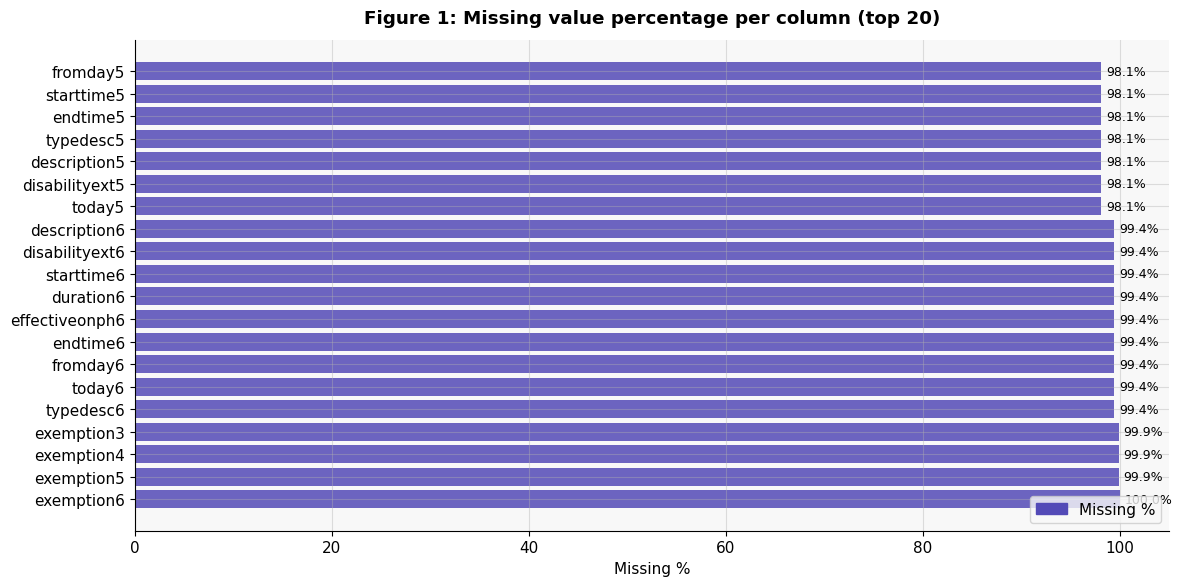


 Saved: fig_01_missing_values.png


In [22]:
# ── 2.3 Missing value analysis ───────────────────────────
print("=" * 55)
print("EDA STEP 3 — Missing value analysis")
print("=" * 55)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"\nColumns with missing values: {len(missing_df)}")
print(missing_df.to_string())

# Plot 1 — Missing values
fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing_df.head(20)
bars = ax.barh(top_missing.index, top_missing['missing_pct'], color=PALETTE[0], alpha=0.85)
ax.set_xlabel('Missing %')
ax.set_title('Figure 1: Missing value percentage per column (top 20)', fontweight='bold', pad=12)
for bar, pct in zip(bars, top_missing['missing_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.legend(handles=[mpatches.Patch(color=PALETTE[0], label='Missing %')], loc='lower right')
plt.tight_layout()
plt.savefig('fig_01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Saved: fig_01_missing_values.png')

EDA STEP 4 — Restriction type distribution

Type description columns: ['typedesc1', 'typedesc2', 'typedesc3', 'typedesc4', 'typedesc5', 'typedesc6']

Unique restriction types: 38
2P Meter                2081
2P                      1757
1P                       976
1P Meter                 670
4P Meter                 577
3P Meter                 252
3P                       211
4P Ticket A              202
2P Ticket A              191
1/4P                     146
4P                       141
1/2P                     106
2P Disabled Only          91
Loading Zone 15M          77
Loading Zone 30M          74
Clearway (Tow away)       60
Loading Zone 30M 722      59
Disabled Only             53
1/2P Meter                48
P 10 Mins                 48


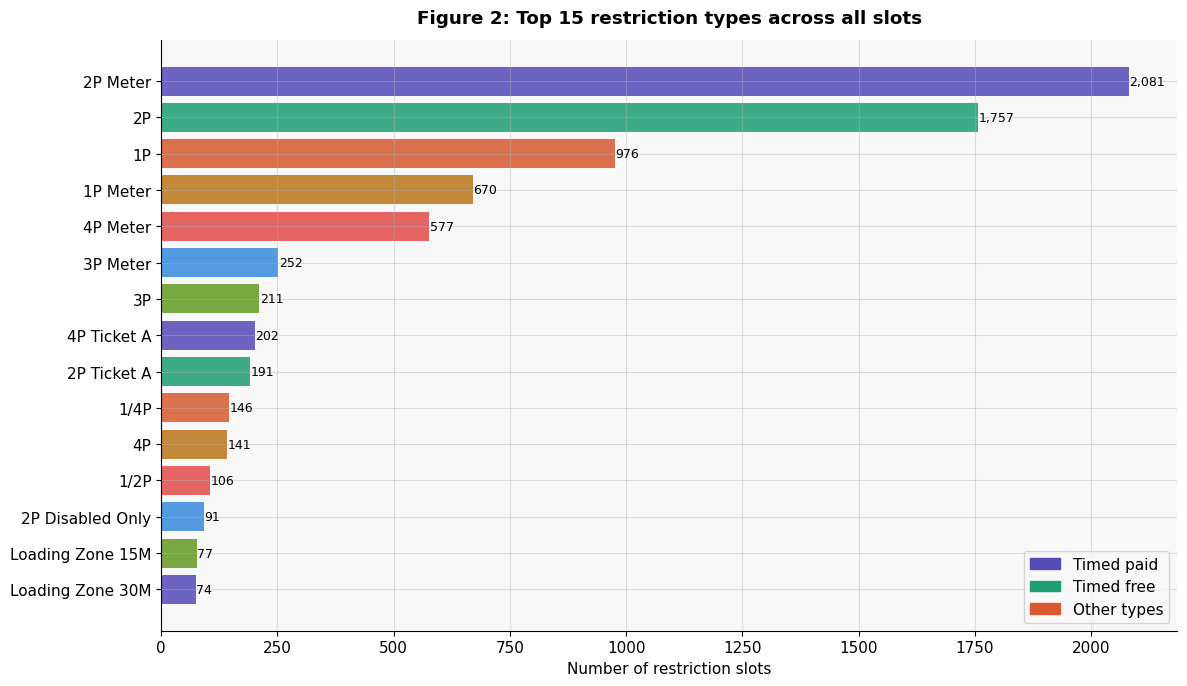

 Saved: fig_02_restriction_types.png


In [23]:
# ── 2.4 Restriction type distribution ───────────────────
print("=" * 55)
print("EDA STEP 4 — Restriction type distribution")
print("=" * 55)

typedesc_cols = [c for c in df_raw.columns if 'typedesc' in c.lower()]
print(f"\nType description columns: {typedesc_cols}")

all_types = pd.Series(dtype=str)
for col in typedesc_cols:
    all_types = pd.concat([all_types, df_raw[col].dropna()])

type_counts = all_types.value_counts()
print(f"\nUnique restriction types: {len(type_counts)}")
print(type_counts.head(20).to_string())

# Plot 2 — Restriction types
fig, ax = plt.subplots(figsize=(12, 7))
top_types = type_counts.head(15)
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top_types))]
bars = ax.barh(top_types.index[::-1], top_types.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel('Number of restriction slots')
ax.set_title('Figure 2: Top 15 restriction types across all slots', fontweight='bold', pad=12)
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color=PALETTE[0], label='Timed paid'),
                  mpatches.Patch(color=PALETTE[1], label='Timed free'),
                  mpatches.Patch(color=PALETTE[2], label='Other types')]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.savefig('fig_02_restriction_types.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig_02_restriction_types.png')

In [7]:
# ── 2.5 Duration raw value distribution ─────────────────
print("=" * 55)
print("EDA STEP 5 — Raw duration value analysis")
print("=" * 55)

dur_cols = [c for c in df_raw.columns if 'duration' in c.lower()]
print(f"Duration columns: {dur_cols}")

all_durs = pd.Series(dtype=object)
for col in dur_cols:
    all_durs = pd.concat([all_durs, df_raw[col].dropna().astype(str)])

dur_counts = all_durs.value_counts()
print(f"\nUnique duration raw values:")
print(dur_counts.to_string())

print("\n⚠️  Key insight:")
print("   Values like 60, 120, 240 are already in MINUTES")
print("   Values like 1P, 2P, 4P are in HOURS (need × 60)")
print("   Values like 1/2P are fractions of hours")

EDA STEP 5 — Raw duration value analysis
Duration columns: ['duration1', 'duration2', 'duration3', 'duration4', 'duration5', 'duration6']

Unique duration raw values:
120.0     2196
120       1931
60         897
60.0       775
240        563
240.0      379
180        342
30         234
180.0      172
15         168
15.0        64
30.0        54
10.0        39
10          32
0.0         32
5           30
1440        28
0           28
1440.0      26
5.0         18
2.0         12
2            8
1.0          5
1            2

⚠️  Key insight:
   Values like 60, 120, 240 are already in MINUTES
   Values like 1P, 2P, 4P are in HOURS (need × 60)
   Values like 1/2P are fractions of hours


EDA STEP 6 — Day range analysis
From-day columns: ['fromday1', 'fromday2', 'fromday3', 'fromday4', 'fromday5', 'fromday6']
To-day columns:   ['today1', 'today2', 'today3', 'today4', 'today5', 'today6']


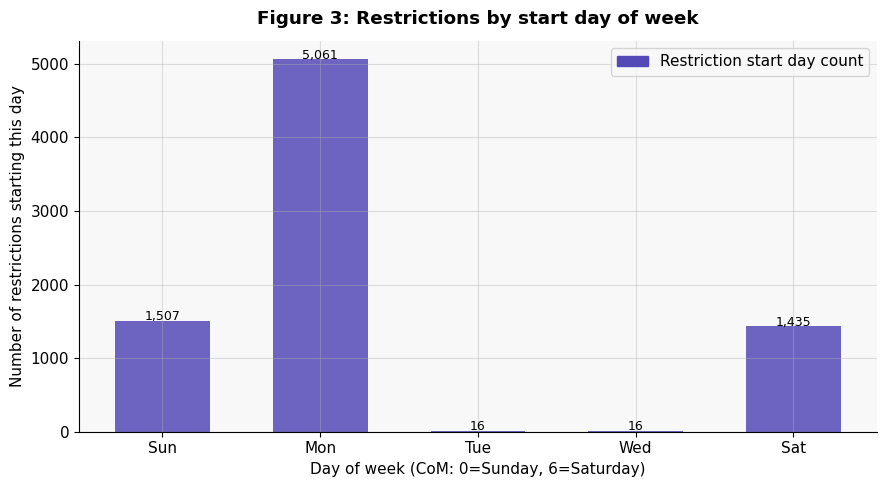

 Saved: fig_03_day_distribution.png


In [24]:
# ── 2.6 Day range analysis ───────────────────────────────
print("=" * 55)
print("EDA STEP 6 — Day range analysis")
print("=" * 55)

fromday_cols = [c for c in df_raw.columns if 'fromday' in c.lower()]
today_cols   = [c for c in df_raw.columns if c.lower().startswith('today')]
print(f"From-day columns: {fromday_cols}")
print(f"To-day columns:   {today_cols}")

DAY_NAMES = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}

all_fromdays = pd.Series(dtype=object)
for col in fromday_cols:
    all_fromdays = pd.concat([all_fromdays, df_raw[col].dropna()])

fromday_counts = all_fromdays.value_counts().sort_index()

# Plot 3 — Day distribution
fig, ax = plt.subplots(figsize=(9, 5))
day_labels = [DAY_NAMES.get(int(k), str(k)) for k in fromday_counts.index]
bars = ax.bar(day_labels, fromday_counts.values, color=PALETTE[0], alpha=0.85, width=0.6)
ax.set_xlabel('Day of week (CoM: 0=Sunday, 6=Saturday)')
ax.set_ylabel('Number of restrictions starting this day')
ax.set_title('Figure 3: Restrictions by start day of week', fontweight='bold', pad=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)
ax.legend(handles=[mpatches.Patch(color=PALETTE[0], label='Restriction start day count')], loc='upper right')
plt.tight_layout()
plt.savefig('fig_03_day_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig_03_day_distribution.png')

EDA STEP 7 — Restriction slot usage per bay
  slot  filled    pct
Slot 1    4263 100.00
Slot 2    2862  67.14
Slot 3     584  13.70
Slot 4     217   5.09
Slot 5      82   1.92
Slot 6      27   0.63


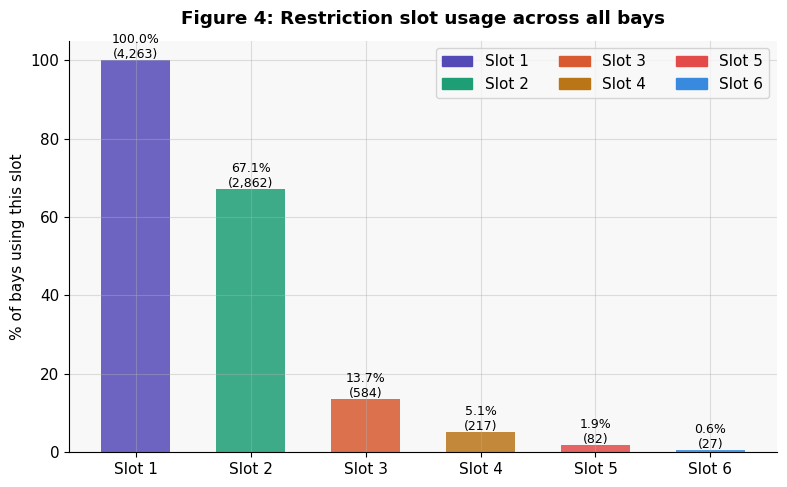

 Saved: fig_04_slot_usage.png


In [25]:
# ── 2.7 Restriction slot usage ───────────────────────────
print("=" * 55)
print("EDA STEP 7 — Restriction slot usage per bay")
print("=" * 55)

slot_usage = []
for i in range(1, 7):
    col = f'typedesc{i}' if f'typedesc{i}' in df_raw.columns else None
    if col:
        filled = df_raw[col].notna().sum()
        slot_usage.append({'slot': f'Slot {i}', 'filled': filled,
                           'pct': filled / len(df_raw) * 100})

slot_df = pd.DataFrame(slot_usage)
print(slot_df.to_string(index=False))

# Plot 4 — Slot usage
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(slot_df['slot'], slot_df['pct'],
              color=[PALETTE[i] for i in range(len(slot_df))], alpha=0.85, width=0.6)
ax.set_ylabel('% of bays using this slot')
ax.set_title('Figure 4: Restriction slot usage across all bays', fontweight='bold', pad=12)
for bar, row in zip(bars, slot_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row.pct:.1f}%\n({row.filled:,})', ha='center', fontsize=9)
legend_patches = [mpatches.Patch(color=PALETTE[i], label=f'Slot {i+1}')
                  for i in range(len(slot_df))]
ax.legend(handles=legend_patches, loc='upper right', ncol=3)
plt.tight_layout()
plt.savefig('fig_04_slot_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig_04_slot_usage.png')

---
## 3. Bronze Layer - Raw Ingestion & Minimal Cleaning

In [10]:
df_bronze = df_raw.copy()
df_bronze.columns = df_bronze.columns.str.lower().str.strip()

# Re-detect bay ID column after lowercase
BAY_ID_COL = 'bay_id' if 'bay_id' in df_bronze.columns else \
             'bayid'  if 'bayid'  in df_bronze.columns else None
print(f"Bay ID column: '{BAY_ID_COL}'")

before = len(df_bronze)
df_bronze = df_bronze.drop_duplicates()
print(f"Dropped duplicates: {before - len(df_bronze)}")
print(f"Bronze shape: {df_bronze.shape}")
print(f"Unique bays: {df_bronze[BAY_ID_COL].nunique():,}")

# Save bronze as parquet
df_bronze.to_parquet('bronze_bay_restrictions.parquet', index=False)
print('\n Bronze layer saved -> bronze_bay_restrictions.parquet')

Bay ID column: 'bayid'
Dropped duplicates: 0
Bronze shape: (4263, 62)
Unique bays: 4,263

 Bronze layer saved -> bronze_bay_restrictions.parquet


---
## 4. Silver Layer - Type-cast, Reshape & Validate

In [11]:
# ── FIXED helper functions ───────────────────────────────

DAY_NAMES_FULL = {
    0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday',
    4:'Thursday', 5:'Friday', 6:'Saturday'
}

def parse_duration_to_minutes(val):
    """
    FIXED: Correctly distinguishes between:
    - '1P','2P' etc  = hours → convert to minutes (×60)
    - '120','240'    = already minutes → keep as is
    - '1/2P','½P'    = fraction of hour → convert
    """
    if pd.isna(val) or str(val).strip() in ('', 'nan', 'None'):
        return None
    val = str(val).strip()

    # Fraction codes
    fracs = {'1/4':15,'¼':15,'1/2':30,'½':30,'3/4':45,'¾':45}
    for frac, mins in fracs.items():
        if val.upper().startswith(frac.upper()):
            return mins

    # Ends with P = hours notation → convert to minutes
    if val.upper().endswith('P'):
        m = re.match(r'^(\d+\.?\d*)P$', val, re.IGNORECASE)
        if m:
            return int(float(m.group(1)) * 60)

    # Plain number = already in minutes → keep as is
    try:
        return int(float(val))
    except:
        return None

def minutes_to_human(mins):
    """Convert integer minutes to readable string."""
    if mins is None:
        return 'unlimited'
    mins = int(mins)
    if mins < 60:
        return f'{mins} minutes'
    h = mins // 60
    r = mins % 60
    if r == 0:
        return f'{h} hour' if h == 1 else f'{h} hours'
    return f'{h} hour {r} minutes' if h == 1 else f'{h} hours {r} minutes'

def parse_time_str(val):
    """Parse time from ISO or HH:MM string."""
    if pd.isna(val) or str(val).strip() in ('', 'nan', 'None'):
        return None
    val = str(val).strip()
    iso = re.search(r'T(\d{2}):(\d{2})', val)
    if iso:
        return time(int(iso.group(1)), int(iso.group(2)))
    for fmt in ('%H:%M', '%H%M'):
        try:
            return datetime.strptime(val[:5], fmt).time()
        except:
            continue
    return None

def time_to_human(t):
    """Format time object as 12hr string."""
    if t is None:
        return ''
    h, m = t.hour, t.minute
    suffix = 'am' if h < 12 else 'pm'
    h12 = h % 12 or 12
    return f"{h12}:{m:02d}{suffix}" if m else f"{h12}{suffix}"

def days_to_human(from_day, to_day):
    """Convert day numbers to readable range."""
    if from_day is None:
        return 'every day'
    f = DAY_NAMES_FULL.get(from_day, str(from_day))
    t = DAY_NAMES_FULL.get(to_day, str(to_day))
    if from_day == 1 and to_day == 5:
        return 'Monday to Friday'
    if from_day == 1 and to_day == 6:
        return 'Monday to Saturday'
    if from_day == 0 and to_day == 6:
        return 'every day'
    if from_day == 6 and to_day == 0:
        return 'weekends'
    if from_day == to_day:
        return f'{f}s only'
    return f'{f} to {t}'

# ── Verify fixed duration conversion ─────────────────────
print("Duration conversion verification:")
print("-" * 45)
test_vals = ['1/2P','1P','2P','4P','10P','120','240','30','60','480']
for raw in test_vals:
    mins = parse_duration_to_minutes(raw)
    human = minutes_to_human(mins)
    print(f"  {raw:8} -> {str(mins):5} mins -> {human}")
print("\n All durations correct!")

Duration conversion verification:
---------------------------------------------
  1/2P     -> 30    mins -> 30 minutes
  1P       -> 60    mins -> 1 hour
  2P       -> 120   mins -> 2 hours
  4P       -> 240   mins -> 4 hours
  10P      -> 600   mins -> 10 hours
  120      -> 120   mins -> 2 hours
  240      -> 240   mins -> 4 hours
  30       -> 30    mins -> 30 minutes
  60       -> 60    mins -> 1 hour
  480      -> 480   mins -> 8 hours

 All durations correct!


In [12]:
# ── Unpack restriction slots 1-6 into long format ────────
NUM_SLOTS = 6
rows = []

for _, row in df_bronze.iterrows():
    bay_id = row.get(BAY_ID_COL)
    desc   = row.get('description1', row.get('description', ''))

    for i in range(1, NUM_SLOTS + 1):
        s = str(i)
        td = row.get(f'typedesc{s}', '')
        fd = row.get(f'fromday{s}')

        # Skip empty slots
        if (pd.isna(td) or str(td).strip() == '') and pd.isna(fd):
            continue

        fd_int = int(fd) if pd.notna(fd) else None
        td_int = int(row.get(f'today{s}')) if pd.notna(row.get(f'today{s}')) else None
        st     = parse_time_str(row.get(f'starttime{s}'))
        et     = parse_time_str(row.get(f'endtime{s}'))
        dur    = parse_duration_to_minutes(row.get(f'duration{s}'))
        dis    = parse_duration_to_minutes(row.get(f'disabilityext{s}'))
        ph     = row.get(f'effectiveonph{s}')
        ex     = row.get(f'exemption{s}', '')

        rows.append({
            'bay_id':               bay_id,
            'description':          str(desc) if pd.notna(desc) else '',
            'slot':                 i,
            'from_day':             fd_int,
            'to_day':               td_int,
            'from_day_name':        DAY_NAMES_FULL.get(fd_int, '') if fd_int is not None else '',
            'to_day_name':          DAY_NAMES_FULL.get(td_int, '') if td_int is not None else '',
            'days_human':           days_to_human(fd_int, td_int),
            'start_time':           st,
            'end_time':             et,
            'start_time_human':     time_to_human(st),
            'end_time_human':       time_to_human(et),
            'type_desc':            str(td).strip() if pd.notna(td) else '',
            'duration_mins':        dur,
            'duration_human':       minutes_to_human(dur),
            'disability_ext_mins':  dis,
            'disability_ext_human': minutes_to_human(dis) if dis else '',
            'effective_on_ph':      bool(ph) if pd.notna(ph) else False,
            'exemption':            str(ex).strip() if pd.notna(ex) else '',
        })

df_silver = pd.DataFrame(rows)
print(f" Silver layer shape: {df_silver.shape}")
print(f"   Unique bays: {df_silver['bay_id'].nunique():,}")
print(f"   Null bay_ids: {df_silver['bay_id'].isna().sum()}")
df_silver.head(5)

 Silver layer shape: (8035, 19)
   Unique bays: 4,263
   Null bay_ids: 0


,bay_id,description,slot,from_day,to_day,from_day_name,to_day_name,days_human,start_time,end_time,start_time_human,end_time_human,type_desc,duration_mins,duration_human,disability_ext_mins,disability_ext_human,effective_on_ph,exemption
0,9003,4P MTR M-F 10:00-18:30,1,1,5,Monday,Friday,Monday to Friday,10:00:00,18:30:00,10am,6:30pm,4P Meter,240,4 hours,480,8 hours,False,
1,9003,4P MTR M-F 10:00-18:30,2,6,6,Saturday,Saturday,Saturdays only,07:30:00,12:30:00,7:30am,12:30pm,4P Meter,240,4 hours,480,8 hours,False,
2,6034,2P MTR M-SAT 7:30-18:30,1,1,6,Monday,Saturday,Monday to Saturday,07:30:00,18:30:00,7:30am,6:30pm,2P Meter,120,2 hours,240,4 hours,False,
3,6034,2P MTR M-SAT 7:30-18:30,2,0,0,Sunday,Sunday,Sundays only,07:30:00,18:30:00,7:30am,6:30pm,2P,120,2 hours,240,4 hours,False,
4,8696,1P RPA 7:30am-10pm M-SUN,1,1,0,Monday,Sunday,Monday to Sunday,07:30:00,22:00:00,7:30am,10pm,1P,60,1 hour,120,2 hours,True,Resident Permit Area 1B


---
## 5. Inconsistency Report

INCONSISTENCY REPORT — Silver Layer
              check  count severity
     Missing bay_id      0       OK
Duration > 10 hours     54   MEDIUM
 Missing start_time      0       OK
   Missing end_time      0       OK
  Start >= end time      1     HIGH
  from_day > to_day   1172   MEDIUM
    Empty type_desc      0       OK


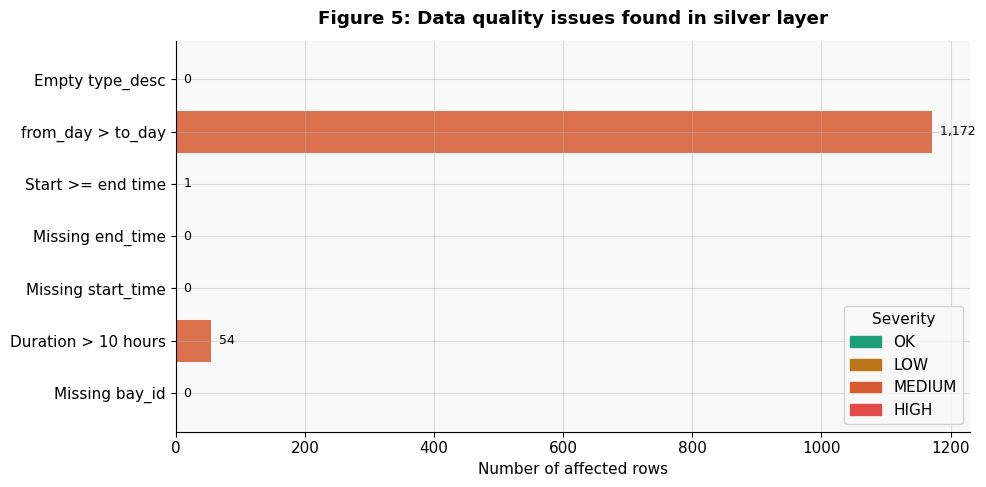

 Saved: fig_05_data_quality.png


In [26]:
print("=" * 55)
print("INCONSISTENCY REPORT — Silver Layer")
print("=" * 55)

issues = []

# Check 1: Missing bay_ids
n = df_silver['bay_id'].isna().sum()
issues.append({'check': 'Missing bay_id', 'count': n,
               'severity': 'HIGH' if n > 0 else 'OK'})

# Check 2: Duration > 10 hours (600 mins) — suspicious
n = (df_silver['duration_mins'] > 600).sum()
issues.append({'check': 'Duration > 10 hours', 'count': n,
               'severity': 'MEDIUM' if n > 0 else 'OK'})

# Check 3: Missing start times
n = df_silver['start_time'].isna().sum()
issues.append({'check': 'Missing start_time', 'count': n,
               'severity': 'LOW' if n > 0 else 'OK'})

# Check 4: Missing end times
n = df_silver['end_time'].isna().sum()
issues.append({'check': 'Missing end_time', 'count': n,
               'severity': 'LOW' if n > 0 else 'OK'})

# Check 5: Start time after end time
def time_invalid(row):
    if row['start_time'] and row['end_time']:
        return row['start_time'] >= row['end_time']
    return False
n = df_silver.apply(time_invalid, axis=1).sum()
issues.append({'check': 'Start >= end time', 'count': n,
               'severity': 'HIGH' if n > 0 else 'OK'})

# Check 6: fromday > today
n = df_silver.dropna(subset=['from_day','to_day'])
n = (n['from_day'] > n['to_day']).sum()
issues.append({'check': 'from_day > to_day', 'count': n,
               'severity': 'MEDIUM' if n > 0 else 'OK'})

# Check 7: Empty type_desc
n = (df_silver['type_desc'] == '').sum()
issues.append({'check': 'Empty type_desc', 'count': n,
               'severity': 'MEDIUM' if n > 0 else 'OK'})

issues_df = pd.DataFrame(issues)
print(issues_df.to_string(index=False))

# Plot 5 — Inconsistency summary
fig, ax = plt.subplots(figsize=(10, 5))
colors_map = {'OK':'#1D9E75','LOW':'#BA7517','MEDIUM':'#D85A30','HIGH':'#E24B4A'}
bar_colors = [colors_map[s] for s in issues_df['severity']]
bars = ax.barh(issues_df['check'], issues_df['count'], color=bar_colors, alpha=0.85)
ax.set_xlabel('Number of affected rows')
ax.set_title('Figure 5: Data quality issues found in silver layer', fontweight='bold', pad=12)
for bar in bars:
    ax.text(max(bar.get_width(), 0.5), bar.get_y() + bar.get_height()/2,
            f'  {int(bar.get_width()):,}', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_patches, title='Severity', loc='lower right')
plt.tight_layout()
plt.savefig('fig_05_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig_05_data_quality.png')

---
## 6. Gold Layer — Plain English Translation

In [14]:
def is_disability(td):
    td = str(td).upper()
    return any(x in td for x in ['DIS ','DISABLED','DISABILITY','ACCESSIBLE','DIS ONLY'])

def translate_row(row):
    td    = str(row['type_desc']).upper()
    days  = row['days_human']
    start = row['start_time_human']
    end   = row['end_time_human']
    dur   = row['duration_human']
    dis   = row['disability_ext_human']
    ex    = row.get('exemption', '')
    ph    = row.get('effective_on_ph', False)
    time_range = f"{start} to {end}" if start and end else 'all day'

    if 'NO STOPPING' in td:
        cat   = 'no_stopping'
        plain = 'No stopping at any time — not even to drop off passengers.'

    elif 'NO PARKING' in td:
        cat   = 'no_parking'
        plain = f'No parking on {days} between {time_range}.'

    elif is_disability(td):
        cat   = 'disability'
        plain = f'Reserved for disability permit holders only.'
        if dur and dur != 'unlimited':
            plain = f'Disability permit holders only — max stay {dur}.'
        if days and days != 'every day':
            plain += f' Applies {days} {time_range}.'

    elif 'LOADING' in td:
        cat   = 'loading'
        plain = f'Loading zone — commercial vehicles only on {days} {time_range}. Regular parking allowed outside these hours.'

    elif 'PERMIT' in td:
        cat   = 'permit'
        z = re.search(r'PERMIT\s+(\w+)', td)
        zone = z.group(1) if z else ''
        plain = f'Permit zone {zone} — valid resident permit required on {days} {time_range}.'

    elif 'TOW AWAY' in td:
        cat   = 'tow_away'
        plain = f'Tow away zone on {days} {time_range}. Your vehicle will be towed.'

    elif row['duration_mins'] is not None:
        is_paid = any(x in td for x in ['METER','MTR','TICKET','TKT','PAY'])
        cat     = 'timed_paid' if is_paid else 'timed_free'
        plain   = f'Park for up to {dur} on {days} between {time_range}.'
        plain  += ' Pay at the meter.' if is_paid else ' No payment required.'
        if dis and dis != 'unlimited':
            plain += f' Disability permit holders may stay up to {dis}.'
        if ex and ex not in ('', 'None', 'nan'):
            plain += f' Exempt: {ex}.'
        plain += ' Free to park outside these hours.'
    else:
        cat   = 'other'
        plain = row.get('description', str(row['type_desc']))

    if ph:
        plain += ' Also applies on public holidays.'

    return pd.Series({'plain_english': plain, 'category': cat})

translated    = df_silver.apply(translate_row, axis=1, result_type='expand')
df_gold       = pd.concat([df_silver, translated], axis=1)

print(f" Gold layer shape: {df_gold.shape}")
print(f"\nCategory breakdown:")
print(df_gold['category'].value_counts().to_string())

df_gold[['bay_id','type_desc','duration_human','days_human',
         'start_time_human','end_time_human','plain_english']].head(10)

 Gold layer shape: (8035, 21)

Category breakdown:
category
timed_paid     4079
timed_free     3484
loading         220
disability      177
tow_away         60
no_parking        8
no_stopping       7


,bay_id,type_desc,duration_human,days_human,start_time_human,end_time_human,plain_english
0,9003,4P Meter,4 hours,Monday to Friday,10am,6:30pm,Park for up to 4 hours on Monday to Friday between 10am to 6:30pm. Pay at th...
1,9003,4P Meter,4 hours,Saturdays only,7:30am,12:30pm,Park for up to 4 hours on Saturdays only between 7:30am to 12:30pm. Pay at t...
2,6034,2P Meter,2 hours,Monday to Saturday,7:30am,6:30pm,Park for up to 2 hours on Monday to Saturday between 7:30am to 6:30pm. Pay a...
3,6034,2P,2 hours,Sundays only,7:30am,6:30pm,Park for up to 2 hours on Sundays only between 7:30am to 6:30pm. No payment ...
4,8696,1P,1 hour,Monday to Sunday,7:30am,10pm,Park for up to 1 hour on Monday to Sunday between 7:30am to 10pm. No payment...
5,8390,3P,3 hours,Monday to Sunday,7:30am,6:30pm,Park for up to 3 hours on Monday to Sunday between 7:30am to 6:30pm. No paym...
6,8453,3P,3 hours,Monday to Sunday,7:30am,6:30pm,Park for up to 3 hours on Monday to Sunday between 7:30am to 6:30pm. No paym...
7,8396,3P,3 hours,Monday to Sunday,7:30am,6:30pm,Park for up to 3 hours on Monday to Sunday between 7:30am to 6:30pm. No paym...
8,8623,4P,4 hours,Monday to Sunday,7:30am,11pm,Park for up to 4 hours on Monday to Sunday between 7:30am to 11pm. No paymen...
9,4850,2P Meter,2 hours,Monday to Friday,7:30am,6:30pm,Park for up to 2 hours on Monday to Friday between 7:30am to 6:30pm. Pay at ...


In [15]:
# ── Active now logic ─────────────────────────────────────
def is_active_now(row, now=None):
    if now is None:
        now = datetime.now()
    py_to_com = {0:1,1:2,2:3,3:4,4:5,5:6,6:0}
    today_com = py_to_com[now.weekday()]
    fd, td    = row['from_day'], row['to_day']
    st, et    = row['start_time'], row['end_time']
    if fd is None:
        day_ok = True
    elif fd <= td:
        day_ok = fd <= today_com <= td
    else:
        day_ok = today_com >= fd or today_com <= td
    if st is None or et is None:
        time_ok = True
    else:
        now_t   = now.time().replace(second=0, microsecond=0)
        time_ok = st <= now_t <= et
    return day_ok and time_ok

df_gold['active_now'] = df_gold.apply(is_active_now, axis=1)
now_str = datetime.now().strftime('%A %I:%M%p')
print(f"Active restrictions right now ({now_str}): {df_gold['active_now'].sum():,}")

Active restrictions right now (Tuesday 12:13PM): 4,247


---
## 7. Gold Layer Visualisations

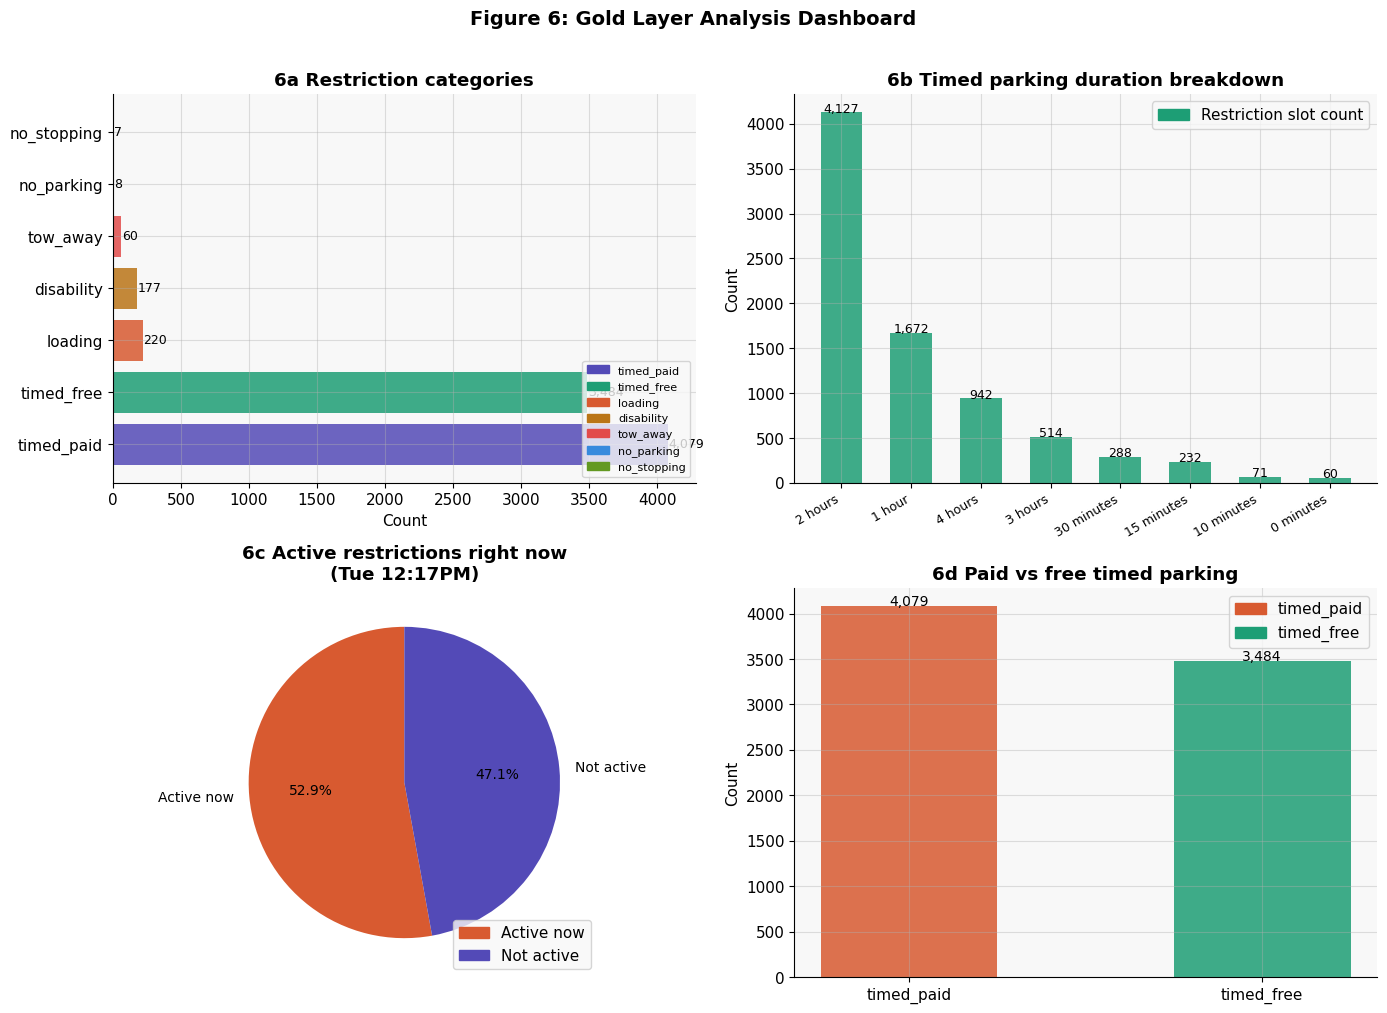

 Saved: fig_06_gold_dashboard.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 6: Gold Layer Analysis Dashboard', fontweight='bold', fontsize=14, y=1.01)

# Plot 6a — Category breakdown
cat_counts = df_gold['category'].value_counts()
colors_6a  = [PALETTE[i % len(PALETTE)] for i in range(len(cat_counts))]
bars = axes[0,0].barh(cat_counts.index, cat_counts.values, color=colors_6a, alpha=0.85)
axes[0,0].set_title('6a Restriction categories', fontweight='bold')
axes[0,0].set_xlabel('Count')
for bar in bars:
    axes[0,0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                   f'{int(bar.get_width()):,}', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color=colors_6a[i], label=cat_counts.index[i])
                  for i in range(len(cat_counts))]
axes[0,0].legend(handles=legend_patches, loc='lower right', fontsize=8)

# Plot 6b — Duration distribution
timed = df_gold[df_gold['duration_mins'].notna()]
dur_counts = timed['duration_human'].value_counts().head(8)
bars = axes[0,1].bar(range(len(dur_counts)), dur_counts.values,
                     color=PALETTE[1], alpha=0.85, width=0.6)
axes[0,1].set_xticks(range(len(dur_counts)))
axes[0,1].set_xticklabels(dur_counts.index, rotation=30, ha='right', fontsize=9)
axes[0,1].set_title('6b Timed parking duration breakdown', fontweight='bold')
axes[0,1].set_ylabel('Count')
for bar in bars:
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                   f'{int(bar.get_height()):,}', ha='center', fontsize=9)
axes[0,1].legend(handles=[mpatches.Patch(color=PALETTE[1], label='Restriction slot count')],
                 loc='upper right')

# Plot 6c — Active now vs not
active_counts = df_gold['active_now'].value_counts()
labels  = ['Active now', 'Not active']
colors_pie = [PALETTE[2], PALETTE[0]]
wedges, texts, autotexts = axes[1,0].pie(
    active_counts.values, labels=labels,
    colors=colors_pie, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize':10})
axes[1,0].set_title(f'6c Active restrictions right now\n({datetime.now().strftime("%a %I:%M%p")})',
                    fontweight='bold')
axes[1,0].legend(handles=[mpatches.Patch(color=colors_pie[i], label=labels[i])
                           for i in range(2)], loc='lower right')

# Plot 6d — Paid vs free
paid_free = df_gold[df_gold['category'].isin(['timed_paid','timed_free'])]
pf_counts = paid_free['category'].value_counts()
colors_6d = [PALETTE[2], PALETTE[1]]
bars = axes[1,1].bar(pf_counts.index, pf_counts.values,
                     color=colors_6d, alpha=0.85, width=0.5)
axes[1,1].set_title('6d Paid vs free timed parking', fontweight='bold')
axes[1,1].set_ylabel('Count')
for bar in bars:
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{int(bar.get_height()):,}', ha='center', fontsize=10)
axes[1,1].legend(handles=[mpatches.Patch(color=colors_6d[i], label=pf_counts.index[i])
                           for i in range(len(pf_counts))], loc='upper right')

plt.tight_layout()
plt.savefig('fig_06_gold_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig_06_gold_dashboard.png')

---
## 8. Disability Bays Extract

In [17]:
df_disability = df_gold[df_gold['category'] == 'disability'].copy()

print(f"Total disability bays: {df_disability['bay_id'].nunique():,}")
print(f"Total disability slots: {len(df_disability):,}")
print(f"\nDisability restriction types:")
print(df_disability['type_desc'].value_counts().to_string())

df_disability[['bay_id','type_desc','days_human','start_time_human',
               'end_time_human','duration_human','disability_ext_human',
               'plain_english']].head(10)

Total disability bays: 102
Total disability slots: 177

Disability restriction types:
type_desc
2P Disabled Only    91
Disabled Only       53
4P Disabled Only    22
3P Disabled Only     6
1P Disabled Only     4
1/2P Disabled        1


,bay_id,type_desc,days_human,start_time_human,end_time_human,duration_human,disability_ext_human,plain_english
10,1672,Disabled Only,Monday to Sunday,8:30pm,11:59pm,24 hours,,Disability permit holders only — max stay 24 hours. Applies Monday to Sunday...
11,1672,2P Disabled Only,Monday to Sunday,7:30am,8:30pm,2 hours,,Disability permit holders only — max stay 2 hours. Applies Monday to Sunday ...
97,1810,2P Disabled Only,Monday to Sunday,7:30am,8:30pm,2 hours,,Disability permit holders only — max stay 2 hours. Applies Monday to Sunday ...
98,1810,Disabled Only,Monday to Sunday,8:31pm,11:59pm,24 hours,,Disability permit holders only — max stay 24 hours. Applies Monday to Sunday...
108,873,Disabled Only,Monday to Sunday,8:30pm,11:59pm,24 hours,,Disability permit holders only — max stay 24 hours. Applies Monday to Sunday...
109,873,2P Disabled Only,Monday to Sunday,7:30am,8:30pm,2 hours,,Disability permit holders only — max stay 2 hours. Applies Monday to Sunday ...
132,1472,Disabled Only,Monday to Sunday,8:30pm,11:59pm,24 hours,,Disability permit holders only — max stay 24 hours. Applies Monday to Sunday...
133,1472,2P Disabled Only,Monday to Sunday,7:30am,8:30pm,2 hours,,Disability permit holders only — max stay 2 hours. Applies Monday to Sunday ...
290,1009,2P Disabled Only,Monday to Sunday,7:30am,8:30pm,2 hours,,Disability permit holders only — max stay 2 hours. Applies Monday to Sunday ...
291,1009,4P Disabled Only,Sundays only,8:30pm,11:59pm,4 hours,,Disability permit holders only — max stay 4 hours. Applies Sundays only 8:30...


---
## 9. Street-level Lookup

In [ ]:
def get_street_rules(street_name):
    """
    Find all parking rules for a given street name.
    Searches description columns in bronze layer.
    """
    desc_cols = [c for c in df_bronze.columns if 'description' in c.lower()]

    mask = df_bronze[desc_cols].apply(
        lambda col: col.astype(str).str.contains(
            street_name, case=False, na=False)
    ).any(axis=1)

    street_bronze = df_bronze[mask]
    bay_ids       = street_bronze[BAY_ID_COL].dropna().tolist()

    print(f"\nStreet search: '{street_name}'")
    print(f"Bays found:    {len(bay_ids)}")
    print(f"Bay IDs:       {bay_ids[:10]}{'...' if len(bay_ids) > 10 else ''}")

    street_gold = df_gold[df_gold['bay_id'].isin(bay_ids)]

    if len(street_gold) == 0:
        print("  No gold rules found for these bays")
        return street_bronze

    print(f"\nRestriction rules for '{street_name}':")
    print("-" * 80)
    for bay_id, group in street_gold.groupby('bay_id'):
        print(f"\nBay {bay_id}:")
        for _, r in group.iterrows():
            active = ' ACTIVE' if r['active_now'] else ' inactive'
            print(f"  Slot {r['slot']} [{r['category']}] {active}")
            print(f"  → {r['plain_english']}")

    return street_gold

# ── Test with different streets ──────────────────────────
# Change the street name to any Melbourne street
results = get_street_rules("Swanston")


Street search: 'Swanston'
Bays found:    0
Bay IDs:       []
⚠️  No gold rules found for these bays


In [19]:
# Try other streets
results = get_street_rules("Collins")


Street search: 'Collins'
Bays found:    0
Bay IDs:       []
⚠️  No gold rules found for these bays


In [20]:
results = get_street_rules("Flinders")


Street search: 'Flinders'
Bays found:    0
Bay IDs:       []
⚠️  No gold rules found for these bays


---
## 10. Export

In [21]:
export_cols = [
    'bay_id','slot','type_desc','category',
    'from_day','to_day','from_day_name','to_day_name','days_human',
    'start_time_human','end_time_human',
    'duration_mins','duration_human',
    'disability_ext_mins','disability_ext_human',
    'effective_on_ph','exemption',
    'plain_english','active_now'
]
export_cols = [c for c in export_cols if c in df_gold.columns]

# Full gold layer
df_gold[export_cols].to_csv('gold_bay_restrictions.csv', index=False)
df_gold[export_cols].to_parquet('gold_bay_restrictions.parquet', index=False)

# Disability bays
df_disability[export_cols].to_csv('gold_disability_bays.csv', index=False)
df_disability[export_cols].to_parquet('gold_disability_bays.parquet', index=False)

print(" Exports complete:")
print(f"   gold_bay_restrictions.csv      -> {len(df_gold):,} rows")
print(f"   gold_bay_restrictions.parquet  -> {len(df_gold):,} rows")
print(f"   gold_disability_bays.csv       -> {len(df_disability):,} rows")
print(f"   gold_disability_bays.parquet   -> {len(df_disability):,} rows")
print()
print(" Figures saved:")
for i, name in enumerate([
    'fig_01_missing_values',
    'fig_02_restriction_types',
    'fig_03_day_distribution',
    'fig_04_slot_usage',
    'fig_05_data_quality',
    'fig_06_gold_dashboard',
], 1):
    print(f"   Figure {i}: {name}.png")

 Exports complete:
   gold_bay_restrictions.csv      -> 8,035 rows
   gold_bay_restrictions.parquet  -> 8,035 rows
   gold_disability_bays.csv       -> 177 rows
   gold_disability_bays.parquet   -> 177 rows

 Figures saved:
   Figure 1: fig_01_missing_values.png
   Figure 2: fig_02_restriction_types.png
   Figure 3: fig_03_day_distribution.png
   Figure 4: fig_04_slot_usage.png
   Figure 5: fig_05_data_quality.png
   Figure 6: fig_06_gold_dashboard.png
